In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [11]:
import random
random.seed(14861251)
state = 14861251
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

### EDA

In [12]:
df = pd.read_csv("musicData.csv")
pd.set_option('display.max_columns', None)
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (50005, 18)


,instance_id,artist_name,track_name,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,obtained_date,valence,music_genre
0,32894.0,Röyksopp,Röyksopp's Night Out,27.0,0.00468,0.652,-1.0,0.941,0.79200,A#,0.115,-5.201,Minor,0.0748,100.889,4-Apr,0.759,Electronic
1,46652.0,Thievery Corporation,The Shining Path,31.0,0.01270,0.622,218293.0,0.890,0.95000,D,0.124,-7.043,Minor,0.0300,115.00200000000001,4-Apr,0.531,Electronic
2,30097.0,Dillon Francis,Hurricane,28.0,0.00306,0.620,215613.0,0.755,0.01180,G#,0.534,-4.617,Major,0.0345,127.994,4-Apr,0.333,Electronic
3,62177.0,Dubloadz,Nitro,34.0,0.02540,0.774,166875.0,0.700,0.00253,C#,0.157,-4.498,Major,0.2390,128.014,4-Apr,0.270,Electronic
4,24907.0,What So Not,Divide & Conquer,32.0,0.00465,0.638,222369.0,0.587,0.90900,F#,0.157,-6.266,Major,0.0413,145.036,4-Apr,0.323,Electronic


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50005 entries, 0 to 50004
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   instance_id       50000 non-null  float64
 1   artist_name       50000 non-null  object 
 2   track_name        50000 non-null  object 
 3   popularity        50000 non-null  float64
 4   acousticness      50000 non-null  float64
 5   danceability      50000 non-null  float64
 6   duration_ms       50000 non-null  float64
 7   energy            50000 non-null  float64
 8   instrumentalness  50000 non-null  float64
 9   key               50000 non-null  object 
 10  liveness          50000 non-null  float64
 11  loudness          50000 non-null  float64
 12  mode              50000 non-null  object 
 13  speechiness       50000 non-null  float64
 14  tempo             50000 non-null  object 
 15  obtained_date     50000 non-null  object 
 16  valence           50000 non-null  float6

Tempo should be numerical so we are converting it and then looking for null values. I find five rows completely null so I drop them entirely as they are useless. There are also ~5k null tempo values.

In [13]:
df['tempo'] = pd.to_numeric(df['tempo'], errors='coerce')

In [14]:
df.isna().sum()

,0
instance_id,5
artist_name,5
track_name,5
popularity,5
acousticness,5
danceability,5
duration_ms,5
energy,5
instrumentalness,5
key,5


In [15]:
df = df.dropna(how='all')

Then I check for invalid values and find ~15k invalid values for instrumentalness, ~5k for tempo and duration. So also I inspect to see if these are commonly occuring together or if there any patterns there and you can see in the cross tab there's no real pattern happening with relation to this missingness, it appears random so I have no cause for concern thus far for moving forward with imputation.

In [9]:
print("Validation Checks")

# Empty strings in 'artist_name' or 'track_name'
empty_artist = df['artist_name'].astype(str).str.strip() == ''
empty_track = df['track_name'].astype(str).str.strip() == ''

print(f"Empty artist names: {empty_artist.sum()}")
print(f"Empty track names: {empty_track.sum()}")

# Popularity < 0 or >= 100
invalid_popularity = df[(df['popularity'] < 0) | (df['popularity'] >= 100)]
print(f"Invalid popularity values (< 0 or ≥ 100): {len(invalid_popularity)}")

# Features that should be in (0, 1]
bounded_cols = ['acousticness', 'danceability', 'energy', 'instrumentalness',
                'liveness', 'speechiness', 'valence']

for col in bounded_cols:
    invalid = df[(df[col] <= 0) | (df[col] > 1)]
    print(f"Values out of [0, 1] in '{col}': {len(invalid)}")

# Duration <= 0
invalid_duration = df[df['duration_ms'] <= 0]
print(f"Invalid durations (≤ 0 ms): {len(invalid_duration)}")

# Tempo <= 0
df['tempo'] = pd.to_numeric(df['tempo'], errors='coerce')
invalid_tempo = df[df['tempo'] <= 0]
print(f"Invalid tempo values (< 0): {len(invalid_tempo)}")

# Empty string in genre
empty_genre = df['music_genre'].astype(str).str.strip() == ''
print(f"Empty genre values: {empty_genre.sum()}")

Validation Checks
Empty artist names: 0
Empty track names: 0
Invalid popularity values (< 0 or ≥ 100): 0
Values out of [0, 1] in 'acousticness': 1
Values out of [0, 1] in 'danceability': 0
Values out of [0, 1] in 'energy': 0
Values out of [0, 1] in 'instrumentalness': 15001
Values out of [0, 1] in 'liveness': 0
Values out of [0, 1] in 'speechiness': 0
Values out of [0, 1] in 'valence': 2
Invalid durations (≤ 0 ms): 4939
Invalid tempo values (< 0): 0
Empty genre values: 0


In [10]:
df_check = df.copy()
df_check['instrumentalness'] = df_check['instrumentalness'].replace(0, np.nan)
df_check['tempo'] = pd.to_numeric(df_check['tempo'], errors='coerce')
df_check.loc[df_check['tempo'] <= 0, 'tempo'] = np.nan
df_check.loc[df_check['duration_ms'] <= 0, 'duration_ms'] = np.nan

missing_counts = df_check[['instrumentalness', 'tempo', 'duration_ms']].isna().sum()
print("Missing values per column:\n", missing_counts)

missing_any = df_check[['instrumentalness', 'tempo', 'duration_ms']].isna().any(axis=1).sum()
print(f"\nRows with any missing: {missing_any}")

missing_all = df_check[['instrumentalness', 'tempo', 'duration_ms']].isna().all(axis=1).sum()
print(f"Rows with all three missing: {missing_all}")

overlap_df = df_check[['instrumentalness', 'tempo', 'duration_ms']].isna()
print("\nOverlap table (sample):")
display(overlap_df.value_counts().rename("Count").reset_index())

Missing values per column:
 instrumentalness    15001
tempo                4980
duration_ms          4939
dtype: int64

Rows with any missing: 21615
Rows with all three missing: 151

Overlap table (sample):


,instrumentalness,tempo,duration_ms,Count
0,False,False,False,28385
1,True,False,False,12175
2,False,True,False,3143
3,False,False,True,3143
4,True,True,False,1358
5,True,False,True,1317
6,False,True,True,328
7,True,True,True,151


Now we do some general exploration to understand the data and find the classes are extremely balanced, which will be good for the classification model to learn all genres equally well.

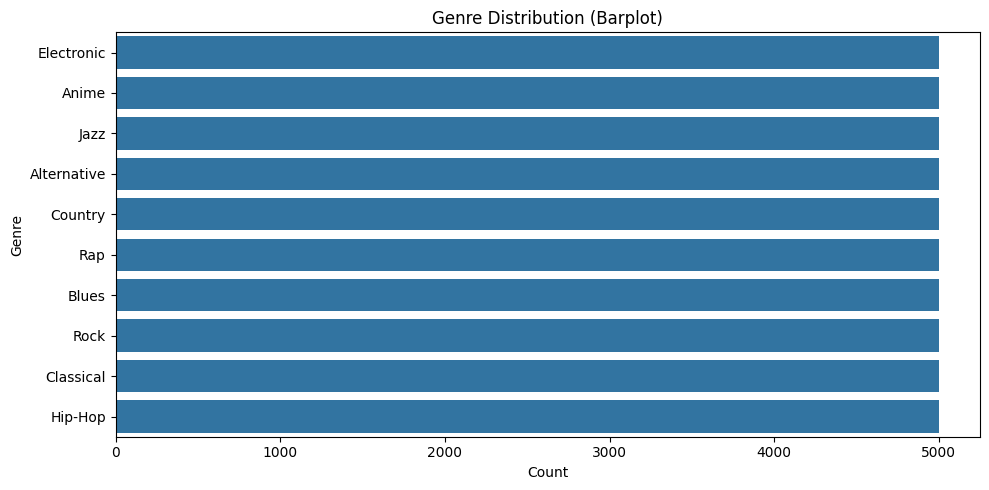

In [ ]:
genre_counts = df["music_genre"].value_counts().reset_index()
genre_counts.columns = ["Genre", "Count"]

plt.figure(figsize=(10, 5))
sns.barplot(data=genre_counts, y="Genre", x="Count", orient='h')
plt.title("Genre Distribution (Barplot)")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

The distributions are a little more interesting. Most of the numerical features are not normally distributed, many with extreme skews. To this extent I determine likely needing to use RF or GBDT because of the tree-based structure that does not assume normality of feautres. If I use Logistic Regression, SVMs, or kNN for example I will have to scale the features to prevent some from dominating due to their larger magnitudes (duration immediately comes to mind as its range is much larger than a lot of these other feaures which are [0,1] ). If I use neural nets I will also need to scale to help the gradients converge more effectively. But I don't think I will use neural nets since that works best with unstructured data, and this is neat tabular data.

Beyond scaling, I want to use tree based models because I have mixed feature types. Tree-based models natively handle categorical features well without needing any linear assumptions. I also likely have nonlinear feature interactions between these features and genre, just based on my rudimentary knowledge of music, and again this is natively supported in tree-based models. They're also more robust to outliers and skew which we see are present in this dataset.



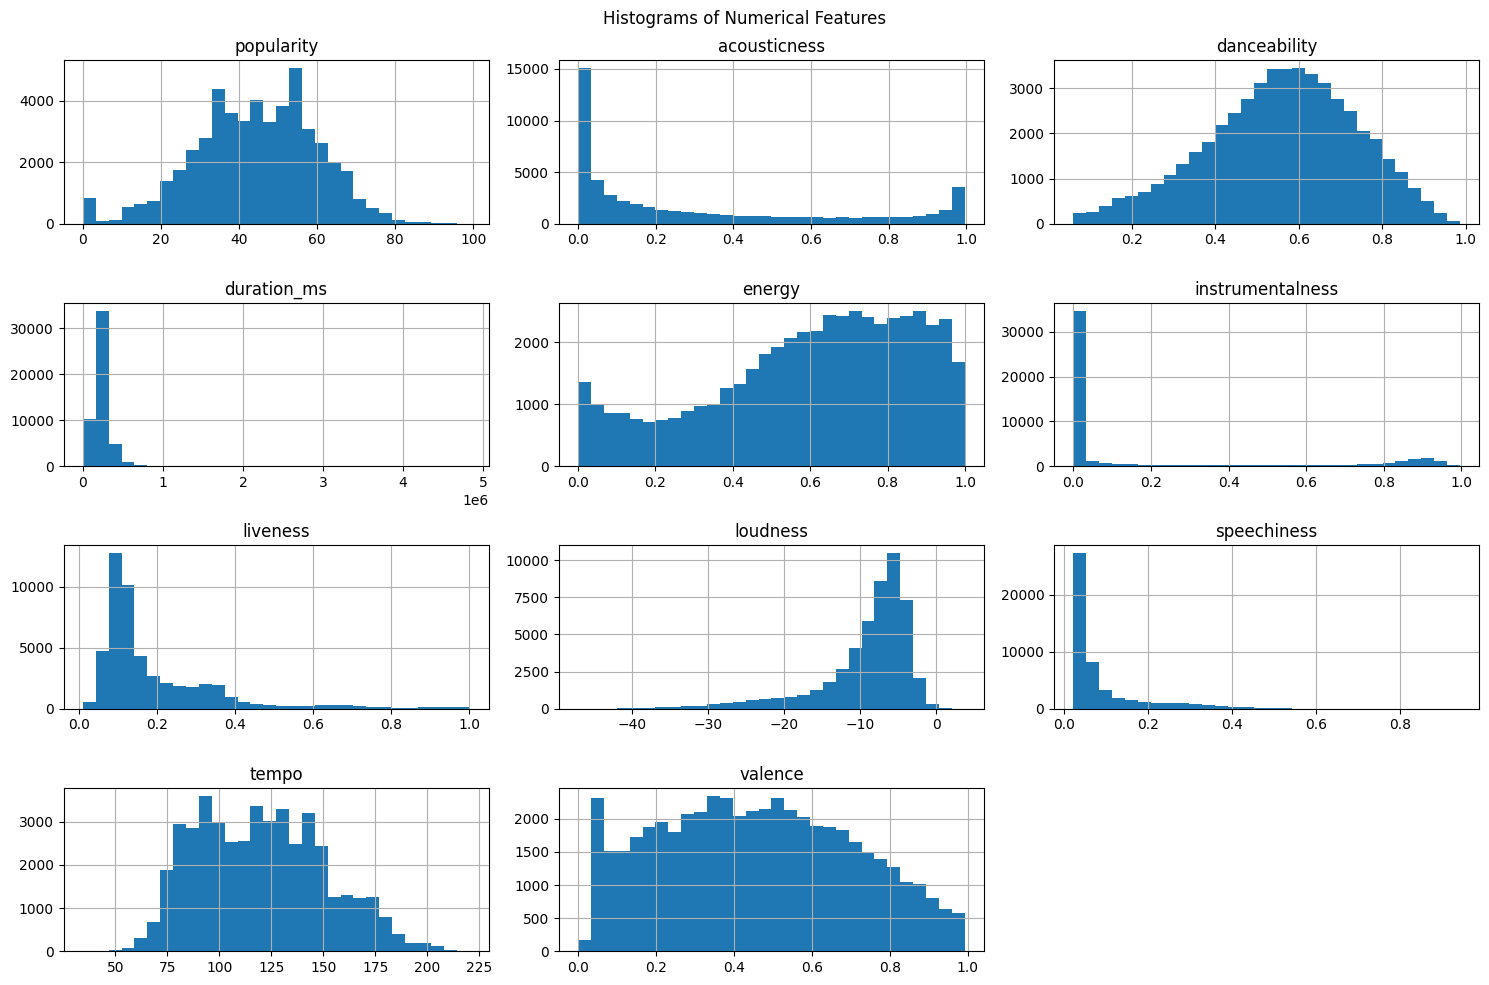

In [20]:
numerical_cols = [
    'popularity', 'acousticness', 'danceability', 'duration_ms', 'energy',
    'instrumentalness', 'liveness', 'loudness', 'speechiness',
    'tempo', 'valence']

df[numerical_cols].hist(figsize=(15, 10), bins=30)
plt.suptitle("Histograms of Numerical Features")
plt.tight_layout()
plt.show()

Note also the mostly weak correlations across the board, with some obvious exceptions such as energy and acousticness or loudness and acousticness. I'm not concerned about collinearity here. Anyway I will be doing PCA which will remove redundancy when it creates orthogonal components and also tree-based models select splits based on information gain so they are already going to ignore redundant features that don't add predictive power.

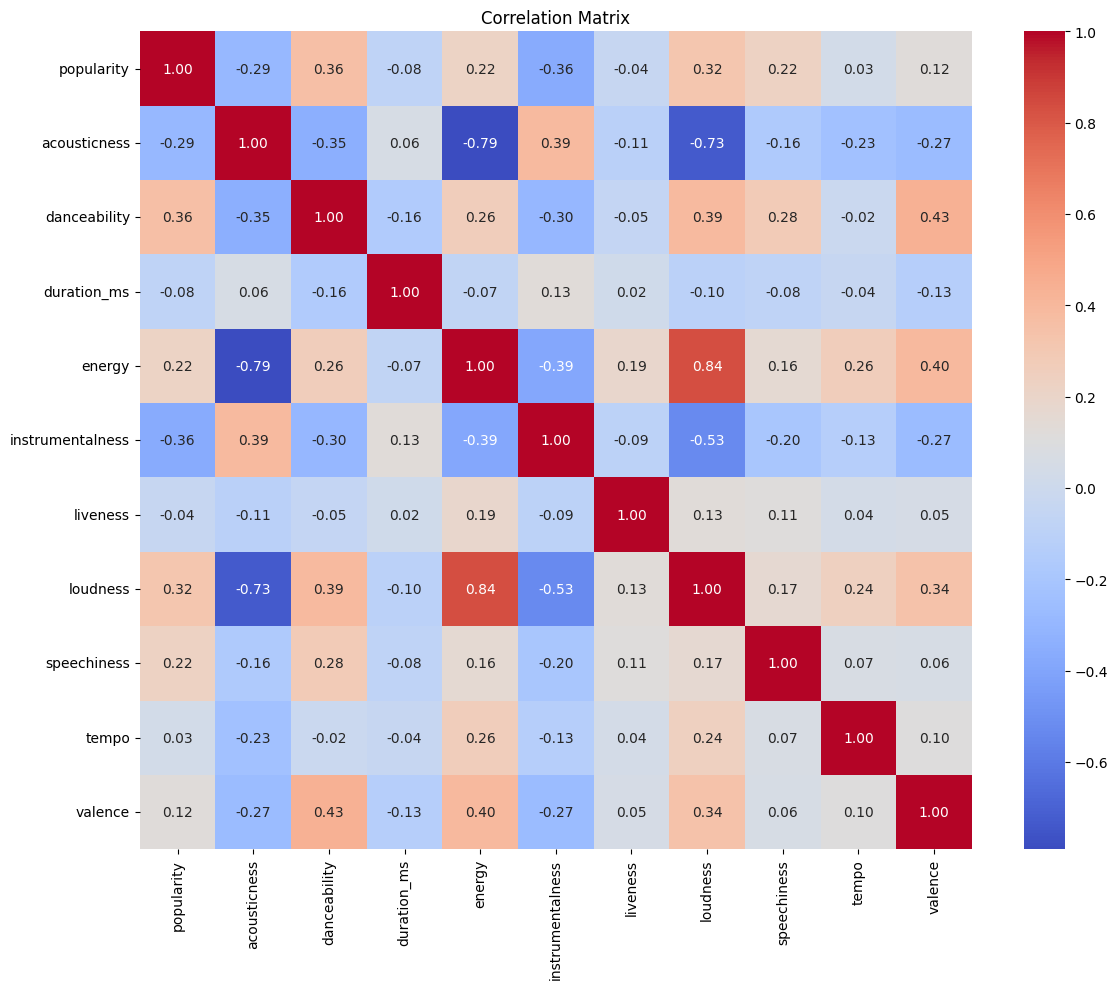

In [ ]:
plt.figure(figsize=(12, 10))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Then I just try to understand what's happening with key and mode. There's definitely more songs in the major mode than minor, and the keys also have some imbalance (very few in D# as compared to G), but nothing of concern to me as these are two of many features the model will use.

In [ ]:
print("Unique values for 'mode':", df['mode'].unique())
print("Unique values for 'key':", df['key'].unique())

Unique values for 'mode': ['Minor' 'Major']
Unique values for 'key': ['A#' 'D' 'G#' 'C#' 'F#' 'B' 'G' 'F' 'A' 'C' 'E' 'D#']


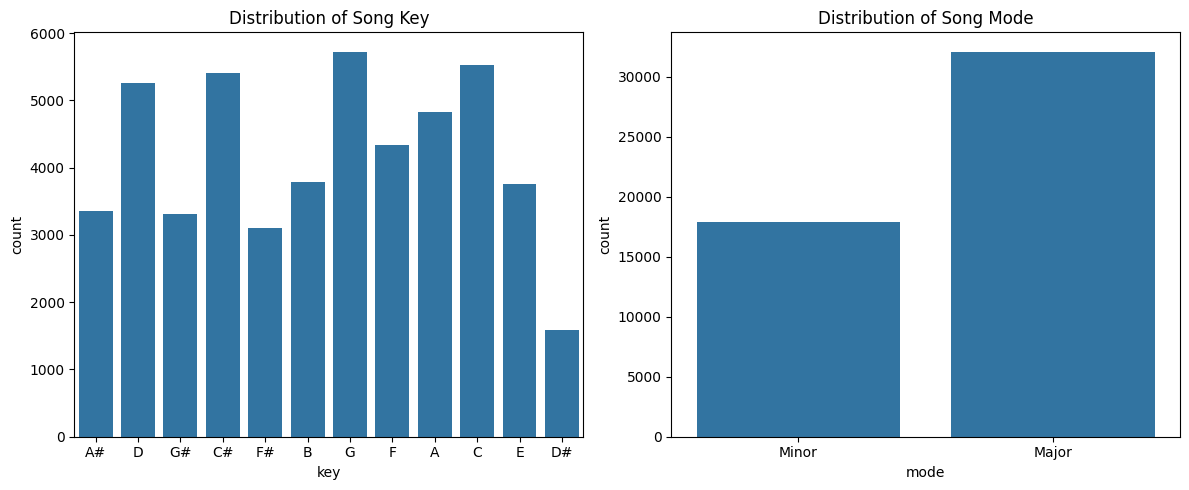

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(ax=axes[0], x='key', data=df)
axes[0].set_title("Distribution of Song Key")

sns.countplot(ax=axes[1], x='mode', data=df)
axes[1].set_title("Distribution of Song Mode")

plt.tight_layout()
plt.show()

Before imputing any features I wanted to understand what was happening with the missingness more. We see the missing tempo is pretty evenly split across genre and the key features for songs with and without it are also very similar. Essentially, there are no concerning patterns and the missingness appears random, so I can probably safely impute these values without introducing bias into the dataset.

Missing tempo counts by genre:
 music_genre
Electronic     534
Blues          530
Country        514
Alternative    505
Anime          503
Classical      500
Rap            496
Hip-Hop        480
Jazz           479
Rock           439
Name: count, dtype: int64


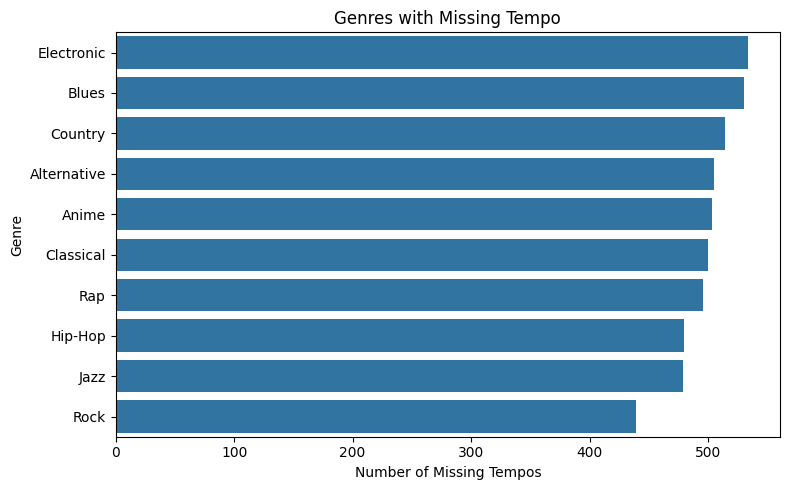


Summary of key features (excluding tempo):

        popularity   duration_ms  acousticness       energy
count  4980.000000  4.980000e+03   4980.000000  4980.000000
mean     43.832530  2.220039e+05      0.304459     0.601577
std      15.429568  1.372552e+05      0.340904     0.265028
min       0.000000 -1.000000e+00      0.000001     0.000900
25%      33.000000  1.756732e+05      0.019500     0.439000
50%      44.000000  2.179830e+05      0.139000     0.647000
75%      55.000000  2.681465e+05      0.555250     0.815000
max      95.000000  4.830606e+06      0.996000     0.999000

 Mean popularity with missing tempo: 43.83
 Mean popularity of all songs: 44.22


In [ ]:
missing_tempo = df[df['tempo'].isna()]

genre_counts = missing_tempo['music_genre'].value_counts()
print("Missing tempo counts by genre:\n", genre_counts)

plt.figure(figsize=(8, 5))
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title("Genres with Missing Tempo")
plt.xlabel("Number of Missing Tempos")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

print("\nSummary of key features (excluding tempo):\n")
print(missing_tempo[['popularity', 'duration_ms', 'acousticness', 'energy']].describe())

mean_pop_missing = missing_tempo['popularity'].mean()
mean_pop_all = df['popularity'].mean()
print(f"\n Mean popularity with missing tempo: {mean_pop_missing:.2f}")
print(f" Mean popularity of all songs: {mean_pop_all:.2f}")

We find the same for duration.

Missing duration counts by genre:
 music_genre
Rap            512
Classical      511
Rock           507
Jazz           497
Country        492
Alternative    491
Hip-Hop        490
Electronic     483
Blues          483
Anime          473
Name: count, dtype: int64


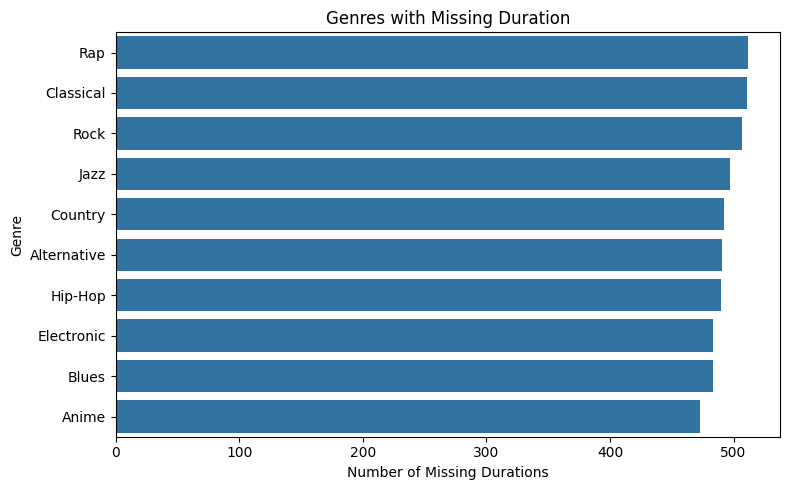


Summary of key features (excluding duration):

        popularity        tempo  acousticness       energy
count  4939.000000  4460.000000   4939.000000  4939.000000
mean     44.099818   120.666286      0.310073     0.593571
std      15.554083    30.530963      0.342431     0.264031
min       0.000000    46.364000      0.000002     0.000953
25%      34.000000    95.064750      0.022150     0.424000
50%      45.000000   120.020000      0.147000     0.633000
75%      56.000000   141.688750      0.570000     0.807000
max      91.000000   220.041000      0.996000     0.998000

 Mean popularity with missing duration: 44.10
 Mean popularity of all songs: 44.22


In [ ]:
missing_duration = df[df['duration_ms'] <= 0]

genre_counts = missing_duration['music_genre'].value_counts()
print("Missing duration counts by genre:\n", genre_counts)

plt.figure(figsize=(8, 5))
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title("Genres with Missing Duration")
plt.xlabel("Number of Missing Durations")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

print("\nSummary of key features (excluding duration):\n")
print(missing_duration[['popularity', 'tempo', 'acousticness', 'energy']].describe())

mean_pop_missing = missing_duration['popularity'].mean()
mean_pop_all = df['popularity'].mean()
print(f"\n Mean popularity with missing duration: {mean_pop_missing:.2f}")
print(f" Mean popularity of all songs: {mean_pop_all:.2f}")

We find more concerning issues with instrumentalness. Much more values are missing for hip-hop than for classsical, to start. This makes me think the missingness isn’t random and is probably reflecting some structural or cultural patterns in the data. For example, hip-hop usually has vocals, so low instrumentalness would make sense and maybe gets recorded as 0 or left blank entirely. The songs missing instrumentalness actually have higher popularity on average as well, which feels important and suggests there might be a real signal tied to those missing values. So this doesn’t look like a safe case for simple global imputation. It’s better to impute within each genre where the context stays consistent.

Missing instrumentalness counts by genre:
 music_genre
Hip-Hop        3193
Rap            3179
Country        2514
Rock           1503
Anime          1434
Alternative    1423
Blues           799
Jazz            537
Electronic      231
Classical       188
Name: count, dtype: int64


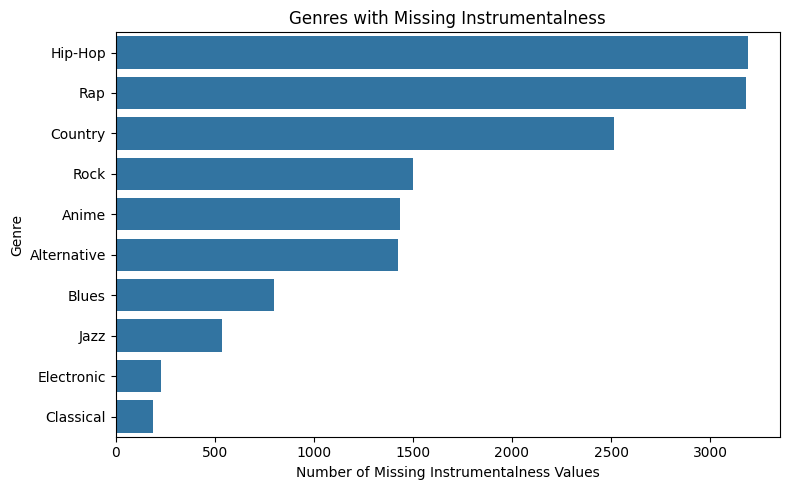


Summary of key features (excluding instrumentalness):

         popularity         tempo  acousticness        energy
count  15001.000000  13492.000000  15001.000000  15001.000000
mean      50.722285    122.672374      0.213109      0.668414
std       14.439379     30.596609      0.244225      0.192810
min        0.000000     40.171000      0.000003      0.003300
25%       43.000000     95.905000      0.026800      0.547000
50%       53.000000    123.439500      0.111000      0.687000
75%       60.000000    144.094250      0.317000      0.820000
max       97.000000    217.538000      0.993000      0.997000

 Mean popularity with missing instrumentalness: 50.72
 Mean popularity of all songs: 44.22


In [ ]:
df['instrumentalness'] = df['instrumentalness'].replace(0, np.nan)
missing_instr = df[df['instrumentalness'].isna()]

genre_counts = missing_instr['music_genre'].value_counts()
print("Missing instrumentalness counts by genre:\n", genre_counts)

plt.figure(figsize=(8, 5))
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title("Genres with Missing Instrumentalness")
plt.xlabel("Number of Missing Instrumentalness Values")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

print("\nSummary of key features (excluding instrumentalness):\n")
print(missing_instr[['popularity', 'tempo', 'acousticness', 'energy']].describe())

mean_pop_missing = missing_instr['popularity'].mean()
mean_pop_all = df['popularity'].mean()
print(f"\n Mean popularity with missing instrumentalness: {mean_pop_missing:.2f}")
print(f" Mean popularity of all songs: {mean_pop_all:.2f}")

First I try to impute all three columns with regression. To this extent, I impute each value with all the rows of that dataset from that same genre, to preserve the context I discussed earlier and hopefully get more reasonable imputations. This is especially tricky for values like instrumentalness which has far more missing values in some genres than others.

In [17]:
from sklearn.linear_model import LinearRegression

df_work = df.copy()
df_work['instrumentalness'] = df_work['instrumentalness'].replace(0, np.nan)
df_work['tempo'] = pd.to_numeric(df_work['tempo'], errors='coerce')
df_work.loc[df_work['tempo'] <= 0, 'tempo'] = np.nan
df_work.loc[df_work['duration_ms'] <= 0, 'duration_ms'] = np.nan

train_rows, test_rows = [], []

for genre, group in df_work.groupby('music_genre'):
    test = group.sample(n=500, random_state=state)
    train = group.drop(test.index)
    test_rows.append(test)
    train_rows.append(train)

df_train = pd.concat(train_rows).reset_index(drop=True)
df_test = pd.concat(test_rows).reset_index(drop=True)

numeric_features = ['popularity', 'energy', 'acousticness', 'danceability',
                    'liveness', 'speechiness', 'valence', 'loudness']
categorical_features = ['mode', 'key']
target_columns = ['instrumentalness', 'tempo', 'duration_ms']

original_train_distributions = df_train[['instrumentalness', 'tempo', 'duration_ms']].copy()
original_test_distributions = df_test[['instrumentalness', 'tempo', 'duration_ms']].copy()

original_train_distributions['tempo'] = pd.to_numeric(original_train_distributions['tempo'], errors='coerce')
original_test_distributions['tempo'] = pd.to_numeric(original_test_distributions['tempo'], errors='coerce')

original_train_distributions.loc[original_train_distributions['tempo'] <= 0, 'tempo'] = np.nan
original_test_distributions.loc[original_test_distributions['tempo'] <= 0, 'tempo'] = np.nan

original_train_distributions.loc[original_train_distributions['duration_ms'] <= 0, 'duration_ms'] = np.nan
original_test_distributions.loc[original_test_distributions['duration_ms'] <= 0, 'duration_ms'] = np.nan

for target in target_columns:
    for genre in df_train['music_genre'].unique():
        train_g = df_train[df_train['music_genre'] == genre].copy()
        valid_g = train_g[train_g[target].notna()]
        missing_g = train_g[train_g[target].isna()]
        test_g = df_test[df_test['music_genre'] == genre].copy()
        missing_test_g = test_g[test_g[target].isna()]

        if valid_g.empty:
            continue

        valid_dum = pd.get_dummies(valid_g[categorical_features], drop_first=False).astype(int)
        missing_dum = pd.get_dummies(missing_g[categorical_features], drop_first=False).astype(int)
        test_dum = pd.get_dummies(missing_test_g[categorical_features], drop_first=False).astype(int)

        all_cols = valid_dum.columns.union(missing_dum.columns).union(test_dum.columns)
        valid_dum = valid_dum.reindex(columns=all_cols, fill_value=0)
        missing_dum = missing_dum.reindex(columns=all_cols, fill_value=0)
        test_dum = test_dum.reindex(columns=all_cols, fill_value=0)

        X_valid = pd.concat([valid_g[numeric_features].reset_index(drop=True), valid_dum.reset_index(drop=True)], axis=1)
        X_missing = pd.concat([missing_g[numeric_features].reset_index(drop=True), missing_dum.reset_index(drop=True)], axis=1)
        X_test = pd.concat([missing_test_g[numeric_features].reset_index(drop=True), test_dum.reset_index(drop=True)], axis=1)

        model = LinearRegression()
        model.fit(X_valid, valid_g[target])

        if not missing_g.empty:
            df_train.loc[missing_g.index, target] = model.predict(X_missing)

        if not missing_test_g.empty:
            df_test.loc[missing_test_g.index, target] = model.predict(X_test)

for col in target_columns:
    print(f"Remaining missing in train '{col}':", df_train[col].isna().sum())
    print(f"Remaining missing in test '{col}':", df_test[col].isna().sum())


Remaining missing in train 'instrumentalness': 0
Remaining missing in test 'instrumentalness': 0
Remaining missing in train 'tempo': 0
Remaining missing in test 'tempo': 0
Remaining missing in train 'duration_ms': 0
Remaining missing in test 'duration_ms': 0


We see the issue with this method below, where the distributions for instrumentalness before and after imputation is very different. Tempo is also quite different, whereas instrumentalness didn't see a huge change.

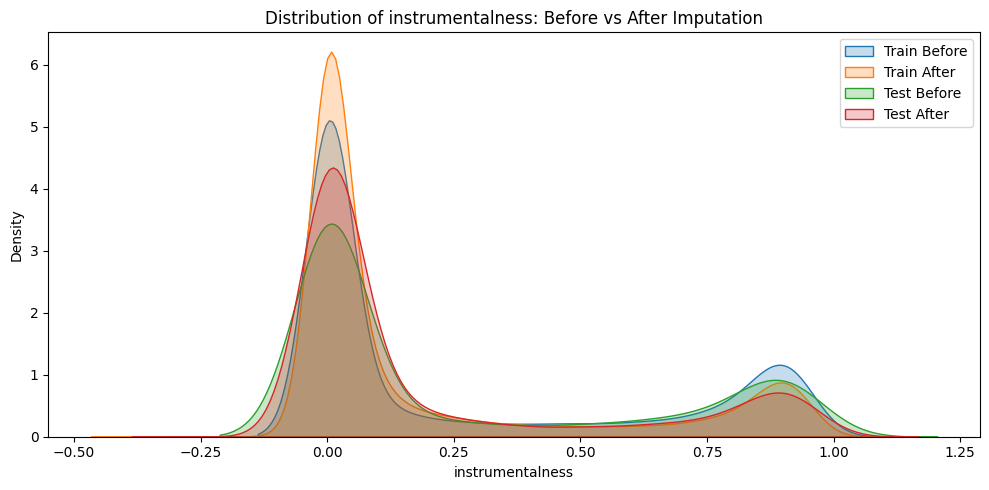

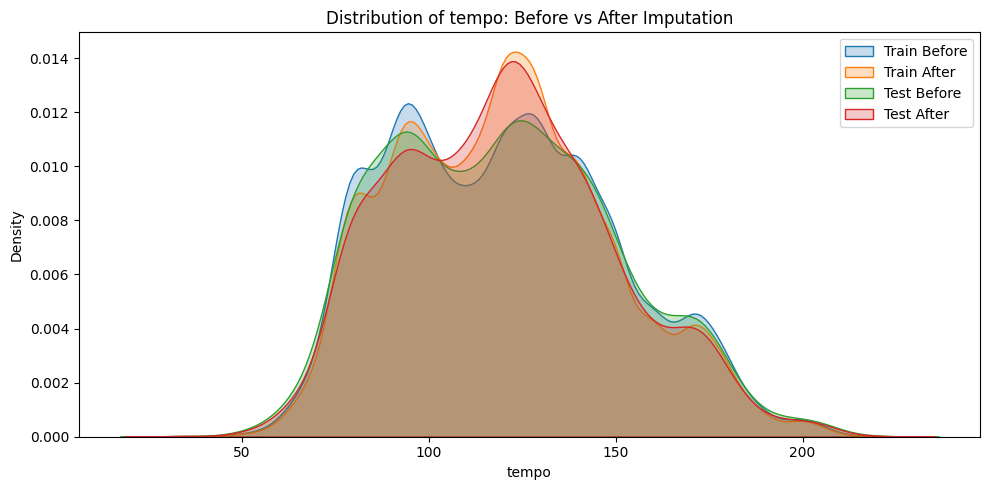

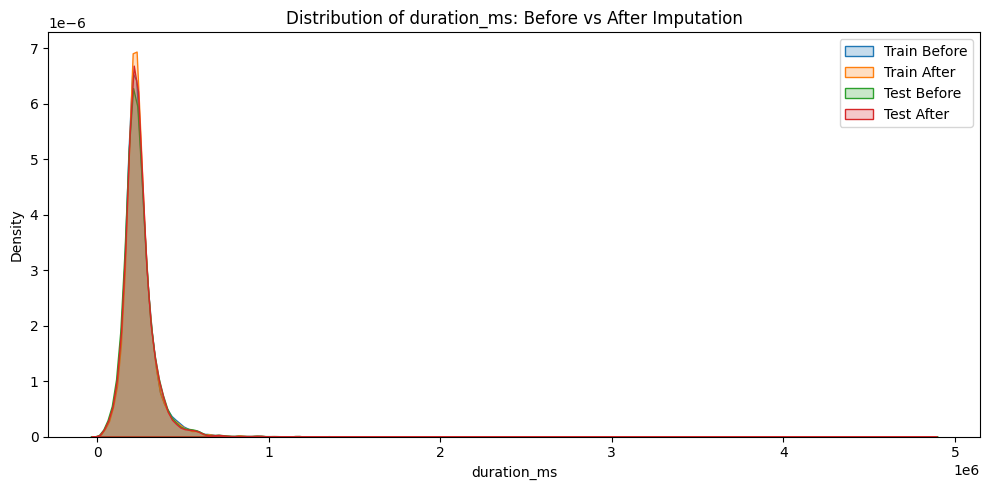

In [ ]:
def plot_before_after(train_column, test_column, feature_name):
    plt.figure(figsize=(10, 5))
    sns.kdeplot(original_train_distributions[feature_name], label="Train Before", fill=True)
    sns.kdeplot(df_train[feature_name], label="Train After", fill=True)
    sns.kdeplot(original_test_distributions[feature_name], label="Test Before", fill=True)
    sns.kdeplot(df_test[feature_name], label="Test After", fill=True)
    plt.title(f"Distribution of {feature_name}: Before vs After Imputation")
    plt.xlabel(feature_name)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_before_after(df_train['instrumentalness'], df_test['instrumentalness'], 'instrumentalness')
plot_before_after(df_train['tempo'], df_test['tempo'], 'tempo')
plot_before_after(df_train['duration_ms'], df_test['duration_ms'], 'duration_ms')

In [ ]:
df_imputed = pd.concat([df_train, df_test], ignore_index=True)

Now we see my earlier concern materialized where imputation has a bunch of values below 0.

In [ ]:
print("Validation Checks After Imputation")

col = 'instrumentalness'
invalid = df_imputed[(df_imputed[col] <= 0) | (df_imputed[col] > 1)]
print(f"Values out of [0, 1] in '{col}': {len(invalid)}")

# Duration <= 0
invalid_duration = df_imputed[df_imputed['duration_ms'] <= 0]
print(f"Invalid durations (≤ 0 ms): {len(invalid_duration)}")

# Tempo <= 0
df_imputed['tempo'] = pd.to_numeric(df_imputed['tempo'], errors='coerce')
invalid_tempo = df_imputed[df_imputed['tempo'] <= 0]
print(f"Invalid tempo values (< 0): {len(invalid_tempo)}")

Validation Checks After Imputation
Values out of [0, 1] in 'instrumentalness': 2974
Invalid durations (≤ 0 ms): 0
Invalid tempo values (< 0): 0


Just to drive the point home I also made the distributions with the regression imputations and we see instrumentalness is very concerning, but so is tempo. duration is the same, on the other hand. This makes sense since tempo had some more class imbalance in missingness than duration as well. There's also much more variation in tempo in general as compared to duration.

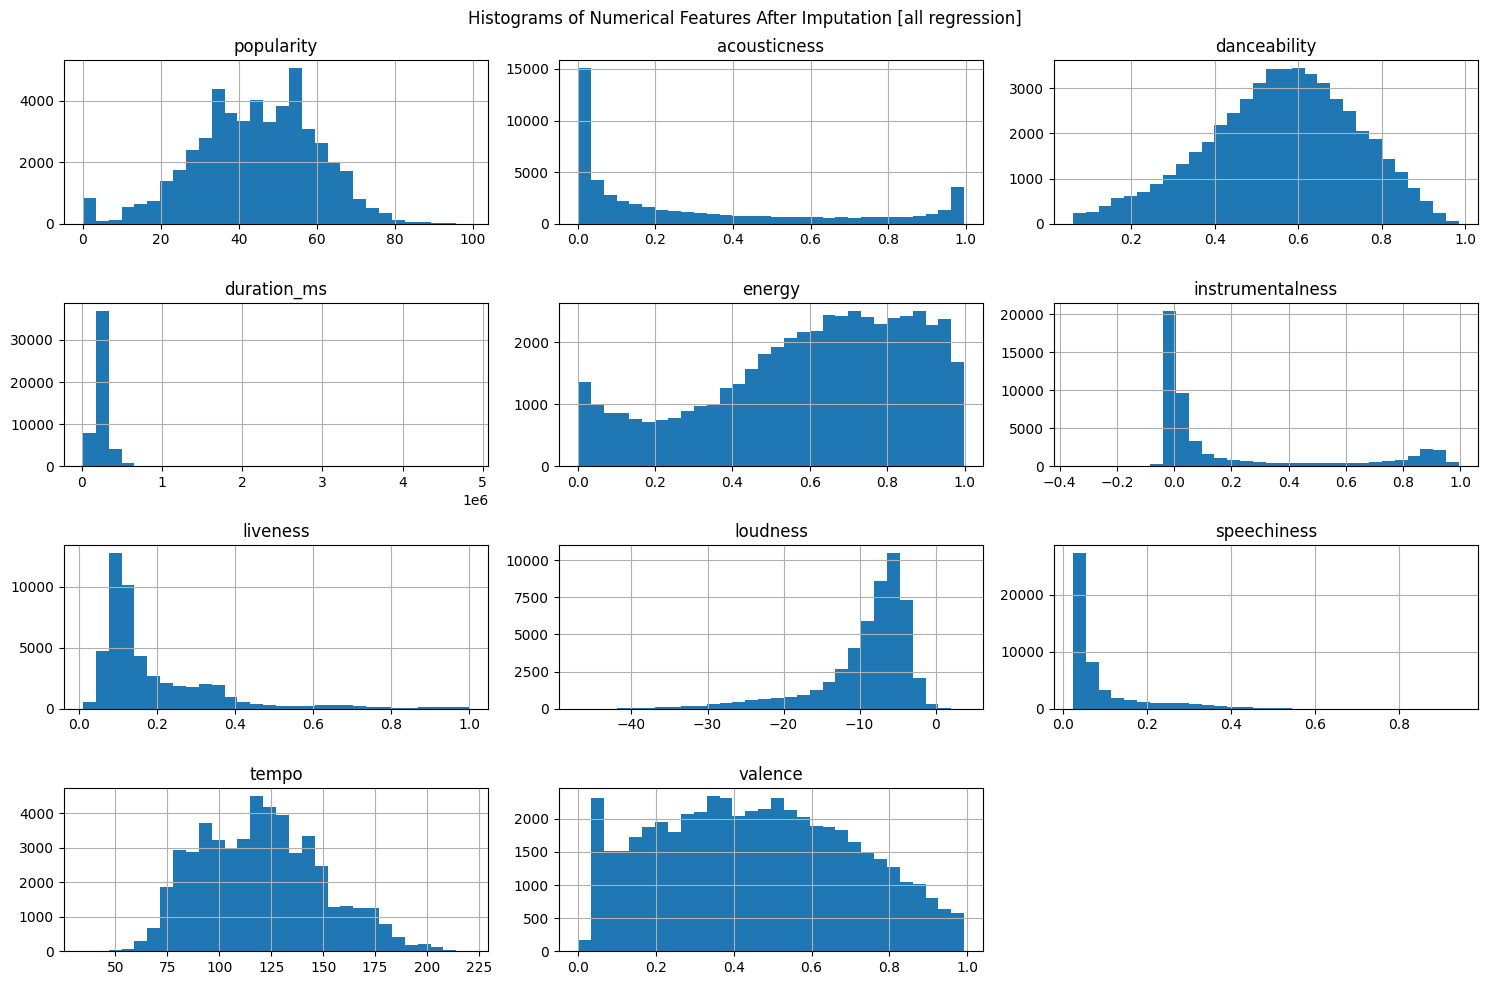

In [ ]:
df_imputed[numerical_cols].hist(figsize=(15, 10), bins=30)
plt.suptitle("Histograms of Numerical Features After Imputation [all regression]")
plt.tight_layout()
plt.show()

As for the correlations I see no concerning differences although correlations for duration and other columns generally went up a tad. I made sure to impute all the columns at once so the imputations were not building of each other, and we see here no concerning correlations between imputed columns, so that method was successful.

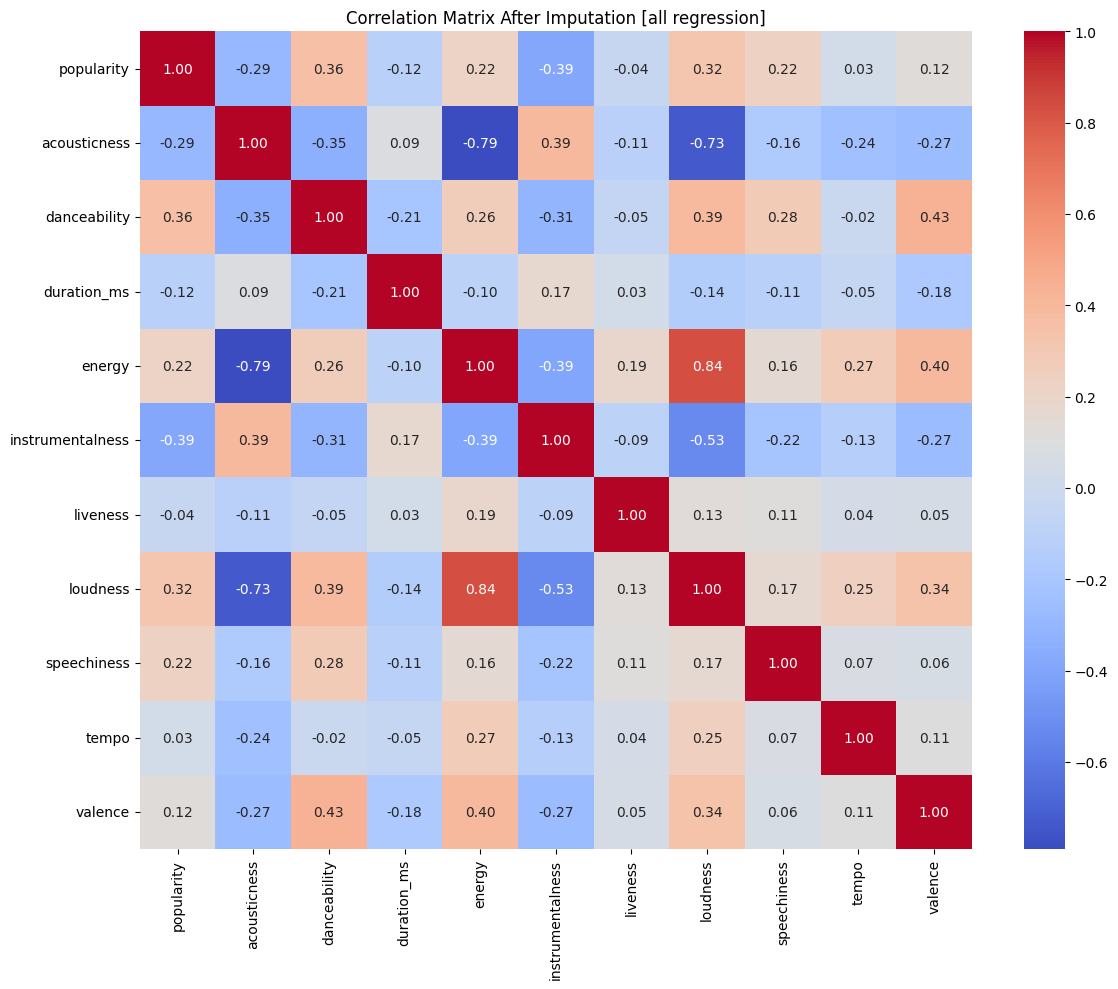

In [ ]:
plt.figure(figsize=(12, 10))
corr = df_imputed[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix After Imputation [all regression]")
plt.tight_layout()
plt.show()

Anyway because of that issue I decided to try imputing only duration with the Linear Regression and using genre-based random sampling to impute tempo and instrumentalness. Tempo has a good range of all possible values to sample from and instrumentalness is on a scale from [0,1] all of which are present in the dataset. I tried to impute by global median and genre based medians in previous experiments not included here just to make this tighter since I basically found those methods weren't great for the distributions either. Anyway in this case, also since I am never using genre to predict or impute any of these values, I am making sure to prevent data leakage. Splitting the data by genre before imputation ensures the imputation is done with genre specific information but without leakage.

In [18]:
df_work = df.copy()
df_work['instrumentalness'] = df_work['instrumentalness'].replace(0, np.nan)
df_work['tempo'] = pd.to_numeric(df_work['tempo'], errors='coerce')
df_work.loc[df_work['tempo'] <= 0, 'tempo'] = np.nan
df_work.loc[df_work['duration_ms'] <= 0, 'duration_ms'] = np.nan

train_rows, test_rows = [], []
for genre, group in df_work.groupby('music_genre'):
    test = group.sample(n=500, random_state=state)
    train = group.drop(test.index)
    test_rows.append(test)
    train_rows.append(train)

df_train = pd.concat(train_rows).reset_index(drop=True)
df_test = pd.concat(test_rows).reset_index(drop=True)

original_train_distributions = df_train[['instrumentalness', 'tempo', 'duration_ms']].copy()
original_test_distributions = df_test[['instrumentalness', 'tempo', 'duration_ms']].copy()

for col in ['instrumentalness', 'tempo', 'duration_ms']:
    original_train_distributions[col] = pd.to_numeric(original_train_distributions[col], errors='coerce')
    original_test_distributions[col] = pd.to_numeric(original_test_distributions[col], errors='coerce')
    original_train_distributions[col] = original_train_distributions[col].replace(0, np.nan)
    original_test_distributions[col] = original_test_distributions[col].replace(0, np.nan)
    original_train_distributions.loc[original_train_distributions[col] <= 0, col] = np.nan
    original_test_distributions.loc[original_test_distributions[col] <= 0, col] = np.nan

numeric_features = ['popularity', 'energy', 'acousticness', 'danceability',
                    'liveness', 'speechiness', 'valence', 'loudness']
categorical_features = ['mode', 'key']

for genre in df_train['music_genre'].unique():
    train_g = df_train[df_train['music_genre'] == genre].copy()
    valid_g = train_g[train_g['duration_ms'].notna()]
    missing_g = train_g[train_g['duration_ms'].isna()]
    test_g = df_test[df_test['music_genre'] == genre].copy()
    missing_test_g = test_g[test_g['duration_ms'].isna()]

    if valid_g.empty:
        continue

    valid_dum = pd.get_dummies(valid_g[categorical_features], drop_first=False).astype(int)
    missing_dum = pd.get_dummies(missing_g[categorical_features], drop_first=False).astype(int)
    test_dum = pd.get_dummies(missing_test_g[categorical_features], drop_first=False).astype(int)

    all_cols = valid_dum.columns.union(missing_dum.columns).union(test_dum.columns)
    valid_dum = valid_dum.reindex(columns=all_cols, fill_value=0)
    missing_dum = missing_dum.reindex(columns=all_cols, fill_value=0)
    test_dum = test_dum.reindex(columns=all_cols, fill_value=0)

    X_valid = pd.concat([valid_g[numeric_features].reset_index(drop=True), valid_dum.reset_index(drop=True)], axis=1)
    X_missing = pd.concat([missing_g[numeric_features].reset_index(drop=True), missing_dum.reset_index(drop=True)], axis=1)
    X_test = pd.concat([missing_test_g[numeric_features].reset_index(drop=True), test_dum.reset_index(drop=True)], axis=1)

    model = LinearRegression()
    model.fit(X_valid, valid_g['duration_ms'])

    if not missing_g.empty:
        df_train.loc[missing_g.index, 'duration_ms'] = np.clip(model.predict(X_missing), 0, None)
    if not missing_test_g.empty:
        df_test.loc[missing_test_g.index, 'duration_ms'] = np.clip(model.predict(X_test), 0, None)

for df_ in [df_train, df_test]:
    for col in ['tempo', 'instrumentalness']:
        for genre in df_['music_genre'].unique():
            missing_idx = df_[(df_['music_genre'] == genre) & (df_[col].isna())].index
            valid_values = df_train[(df_train['music_genre'] == genre) & (df_train[col].notna())][col].values

            if len(valid_values) > 0 and len(missing_idx) > 0:
                df_.loc[missing_idx, col] = np.random.choice(valid_values, size=len(missing_idx), replace=True)

for col in ['instrumentalness', 'tempo', 'duration_ms']:
    print(f"Remaining missing in train '{col}':", df_train[col].isna().sum())
    print(f"Remaining missing in test '{col}':", df_test[col].isna().sum())


Remaining missing in train 'instrumentalness': 0
Remaining missing in test 'instrumentalness': 0
Remaining missing in train 'tempo': 0
Remaining missing in test 'tempo': 0
Remaining missing in train 'duration_ms': 0
Remaining missing in test 'duration_ms': 0


Instrumentalness still looks quite different after imputation but this is to an extent expected since there's 15k missing values from a dataset of only 50k (very large chunk). I originally considered dropping instrumentalness altogether but decided against it in the end since the dataset is so high dimensional I figured a tree-based model would not give it much importance anyway in cases where it harmed the classification prediction. We see a significant improvement in the distributions for tempo.

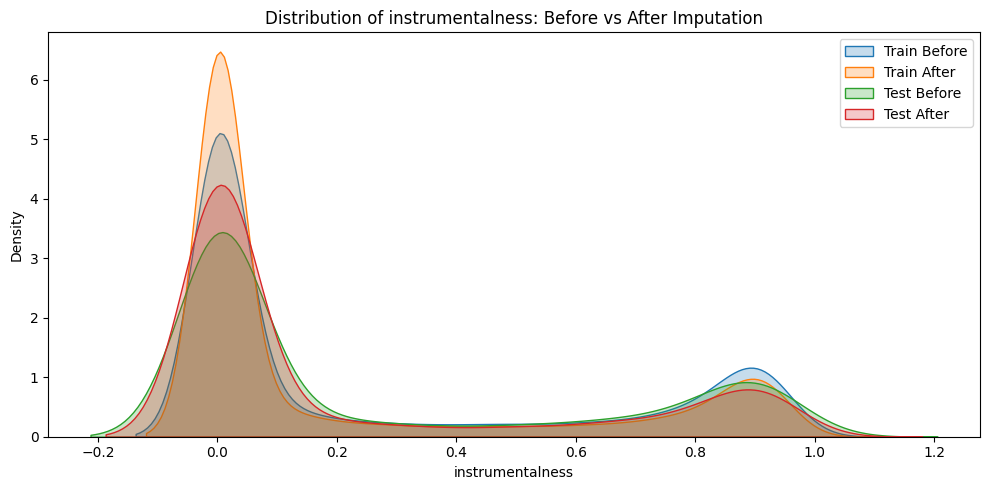

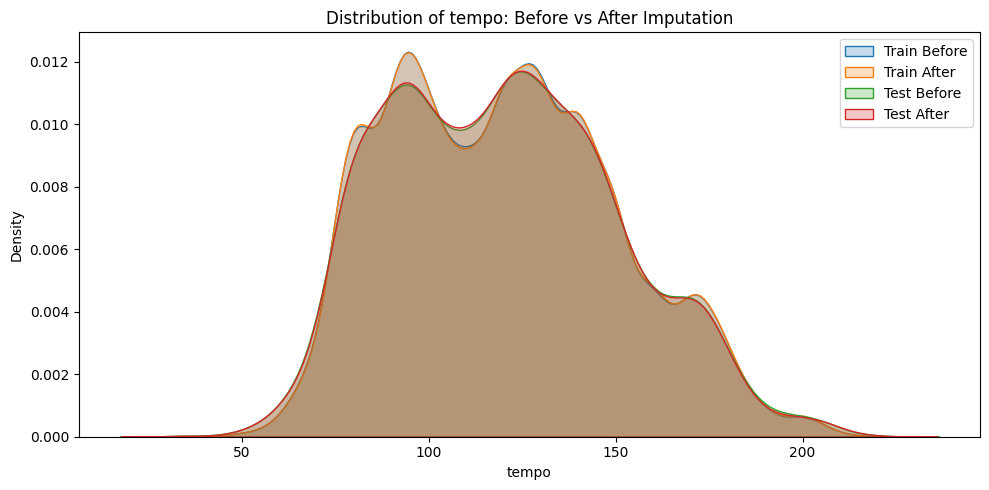

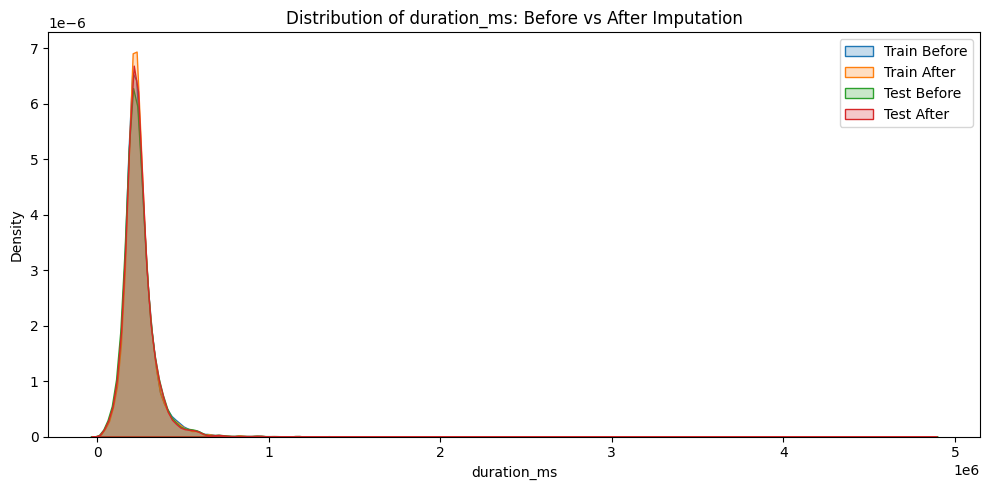

In [ ]:
def plot_before_after(train_column, test_column, feature_name):
    plt.figure(figsize=(10, 5))
    sns.kdeplot(original_train_distributions[feature_name], label="Train Before", fill=True)
    sns.kdeplot(df_train[feature_name], label="Train After", fill=True)
    sns.kdeplot(original_test_distributions[feature_name], label="Test Before", fill=True)
    sns.kdeplot(df_test[feature_name], label="Test After", fill=True)
    plt.title(f"Distribution of {feature_name}: Before vs After Imputation")
    plt.xlabel(feature_name)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_before_after(df_train['instrumentalness'], df_test['instrumentalness'], 'instrumentalness')
plot_before_after(df_train['tempo'], df_test['tempo'], 'tempo')
plot_before_after(df_train['duration_ms'], df_test['duration_ms'], 'duration_ms')

In [ ]:
df_imputed = pd.concat([df_train, df_test], ignore_index=True)

As expected, no invalid values with this method!

In [ ]:
print("Validation Checks After Imputation")

col = 'instrumentalness'
invalid = df_imputed[(df_imputed[col] <= 0) | (df_imputed[col] > 1)]
print(f"Values out of [0, 1] in '{col}': {len(invalid)}")

# Duration <= 0
invalid_duration = df_imputed[df_imputed['duration_ms'] <= 0]
print(f"Invalid durations (≤ 0 ms): {len(invalid_duration)}")

# Tempo <= 0
df_imputed['tempo'] = pd.to_numeric(df_imputed['tempo'], errors='coerce')
invalid_tempo = df_imputed[df_imputed['tempo'] <= 0]
print(f"Invalid tempo values (< 0): {len(invalid_tempo)}")

Validation Checks After Imputation
Values out of [0, 1] in 'instrumentalness': 0
Invalid durations (≤ 0 ms): 0
Invalid tempo values (< 0): 0


The distributions look way better now! No big changes before and after imputation. This is good because means the imputation process preserved the original structure and variability of the data, rather than artificially smoothing it out or introducing bias. That’s especially important here since we're using the imputed features (like tempo and instrumentalness) as inputs in classification and clustering models. If the distributions had shifted significantly, the models might have learned patterns that don't actually exist in the original data. So this gives me more confidence that the models are learning from data that still reflects the real-world variation.

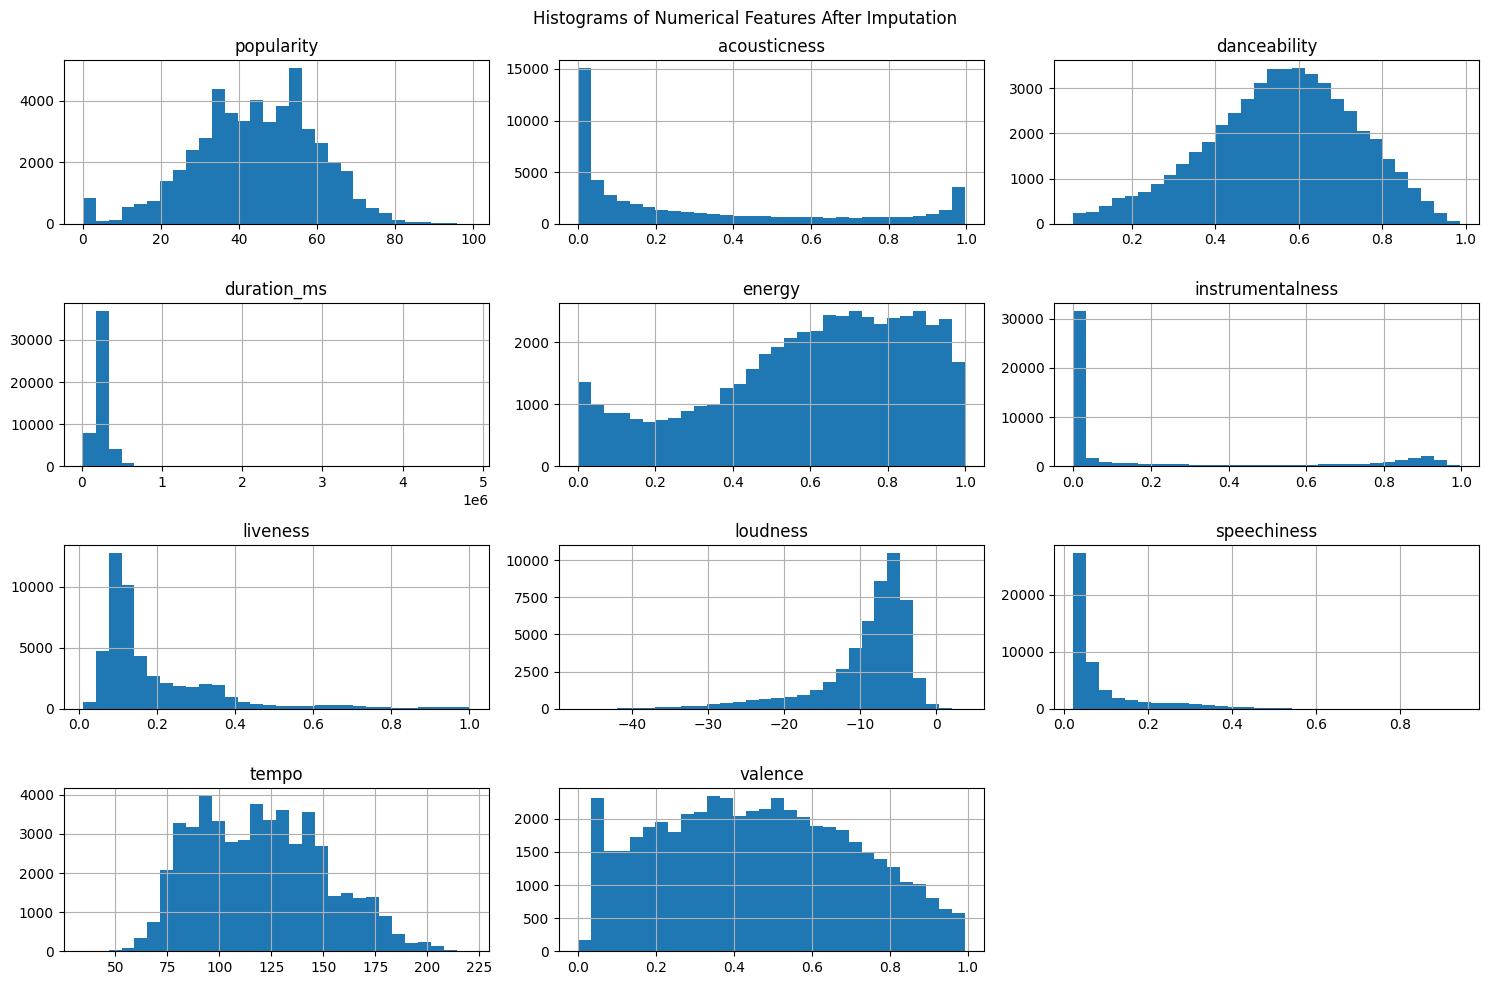

In [ ]:
df_imputed[numerical_cols].hist(figsize=(15, 10), bins=30)
plt.suptitle("Histograms of Numerical Features After Imputation")
plt.tight_layout()
plt.show()

To this extent we also don't see any large or concerning shifts in the correlation map, which is again good.

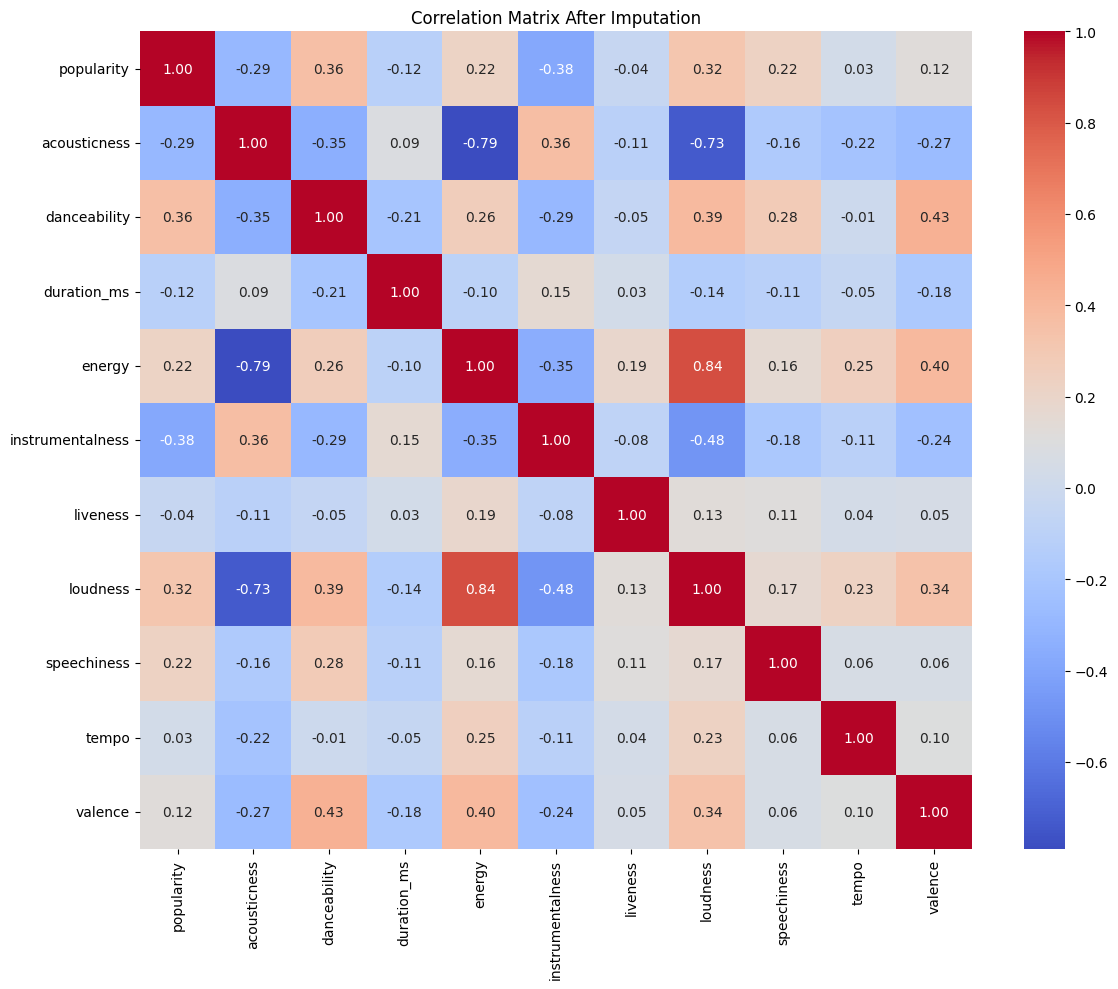

In [ ]:
plt.figure(figsize=(12, 10))
corr = df_imputed[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix After Imputation")
plt.tight_layout()
plt.show()

In [ ]:
df_train

,instance_id,artist_name,track_name,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,obtained_date,valence,music_genre
0,34428.0,Type O Negative,Love You to Death,48.0,0.35900,0.423,428800.0,0.738,0.084000,F#,0.0801,-7.329,Major,0.0319,111.414,4-Apr,0.276,Alternative
1,76036.0,Atmosphere,Puppets,46.0,0.29900,0.733,221787.0,0.444,0.000003,E,0.1040,-7.170,Major,0.1150,89.106,4-Apr,0.372,Alternative
2,37341.0,Hawk Nelson,Never Let You Down,43.0,0.29700,0.666,262560.0,0.740,0.000012,G,0.1450,-5.908,Minor,0.0375,124.911,4-Apr,0.620,Alternative
3,85209.0,Nothing But Thieves,Honey Whiskey,49.0,0.02360,0.561,191947.0,0.764,0.000014,C#,0.2090,-5.175,Major,0.0422,90.004,4-Apr,0.657,Alternative
4,26964.0,The Score,Where You Are,43.0,0.00972,0.652,226333.0,0.813,0.000041,F#,0.2900,-4.737,Major,0.0410,124.000,4-Apr,0.560,Alternative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,48430.0,Led Zeppelin,Immigrant Song - 1990 Remaster,61.0,0.00031,0.574,145067.0,0.926,0.478000,B,0.3860,-10.790,Major,0.0562,113.097,4-Apr,0.609,Rock
44996,84481.0,A Perfect Circle,The Package,53.0,0.00358,0.765,460493.0,0.397,0.715000,A,0.1170,-10.538,Major,0.0359,123.890,4-Apr,0.150,Rock
44997,61577.0,James Taylor,Sweet Baby James,60.0,0.44200,0.512,171093.0,0.239,0.000004,D,0.0930,-15.055,Major,0.0353,141.292,3-Apr,0.634,Rock
44998,50216.0,The Modern Lovers,Pablo Picasso,55.0,0.00269,0.617,261600.0,0.729,0.131000,D,0.1090,-9.174,Major,0.0306,109.638,4-Apr,0.835,Rock


No we will do all the formatting to get the train and test splits I will need for the next steps. This includes standard scaling and encoding labels for categorical columns.

In [21]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

drop_cols = ['artist_name', 'track_name', 'obtained_date', 'instance_id']
df_train = df_train.drop(columns=[col for col in drop_cols if col in df_train.columns])
df_test = df_test.drop(columns=[col for col in drop_cols if col in df_test.columns])

le_key = LabelEncoder()
df_train['key'] = le_key.fit_transform(df_train['key'])
df_test['key'] = le_key.transform(df_test['key'])

df_train['mode'] = df_train['mode'].map({'Major': 1, 'Minor': 0})
df_test['mode'] = df_test['mode'].map({'Major': 1, 'Minor': 0})

y_train = df_train['music_genre']
y_test = df_test['music_genre']

X_train = df_train.drop(columns=['music_genre'])
X_test = df_test.drop(columns=['music_genre'])

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train[numerical_cols]),
                              columns=numerical_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test[numerical_cols]),
                             columns=numerical_cols, index=X_test.index)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

I chose PCA because it keeps the global structure of the data and gives you actual principal components that are linear combinations of the original features that can be traced back so I can understand and interpret, unlike t-SNE or other methods. PCA also works well when features are on different scales after standardization, so I felt based on what I learned about my data it would be a good fit. n_components was 0.95 so I could keep enough information still train accurate models without losing too much variation. We see after PCA now we have 9 dimensions! The first two PCs explain very little of the variation though, 0.33 and then 0.12 respectively so combined it's still less than half. This makes it not great for visualizing the clusters and such as we will soon see.

In [ ]:
pca = PCA(n_components=0.95, random_state=state)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Reduced dimensions: {X_train_pca.shape[1]}")

Reduced dimensions: 9


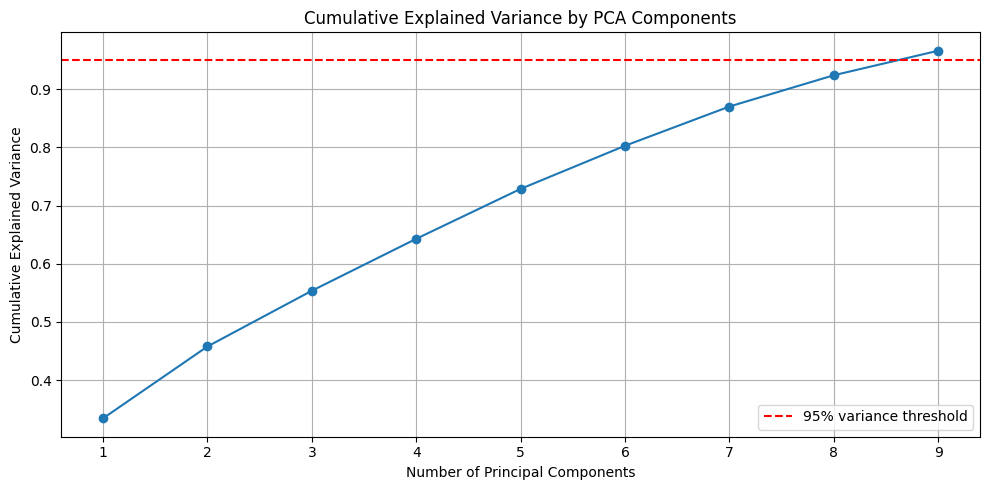

In [ ]:
explained_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(explained_var)+1), explained_var, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance threshold')
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f} variance explained")

PC1: 0.3344 variance explained
PC2: 0.1235 variance explained
PC3: 0.0958 variance explained
PC4: 0.0893 variance explained
PC5: 0.0858 variance explained
PC6: 0.0741 variance explained
PC7: 0.0674 variance explained
PC8: 0.0537 variance explained
PC9: 0.0421 variance explained


PC1, which explains the most variance, is dominated by loudness, energy, and acousticness. These all intuitively go together and probably capture a kind of "intensity" or production quality axis across songs. PC2 has more rhythmic and structural elements like danceability, tempo, and duration, while also pulling in popularity. PC3 surprised me a bit since it’s heavily influenced by speechiness and liveness, which makes me think it might be picking up on performance or vocal presence, maybe distinguishing spoken-word or live tracks. Across PC4 and PC5, duration keeps showing up, often alongside valence and tempo, which tells me those features contribute meaningful variation across genres.

In [ ]:
original_features = X_train_scaled.columns

loadings = pd.DataFrame(pca.components_, columns=original_features, index=[f'PC{i+1}' for i in range(pca.n_components_)])

for i in range(5):
    print(f"\nTop contributors to PC{i+1}:")
    print(loadings.iloc[i].abs().sort_values(ascending=False).head(5))


Top contributors to PC1:
loudness            0.456477
energy              0.438285
acousticness        0.425013
instrumentalness    0.319867
danceability        0.307584
Name: PC1, dtype: float64

Top contributors to PC2:
danceability    0.436519
popularity      0.375010
duration_ms     0.352376
liveness        0.339296
tempo           0.334480
Name: PC2, dtype: float64

Top contributors to PC3:
speechiness    0.602797
liveness       0.592013
valence        0.375191
duration_ms    0.210299
popularity     0.207859
Name: PC3, dtype: float64

Top contributors to PC4:
liveness            0.522302
duration_ms         0.500653
valence             0.438873
popularity          0.437682
instrumentalness    0.179052
Name: PC4, dtype: float64

Top contributors to PC5:
tempo          0.778808
duration_ms    0.399980
speechiness    0.288024
valence        0.248002
liveness       0.193344
Name: PC5, dtype: float64


I decided to run silhouette scores and plot the curve to see if the elbow was at k=10. If it was, that suggests the PCA and clustering is picking up on some patterns genuinely present in the data (as we have 10 genres). Unfortunately, the curve was very wonky, increasing and decreasing with no clear elbow at k=10, indicating that the PCA=reduced space may not separate the genres in a way that's meaningful for unsupervised clustering.

k=2, silhouette score = 0.3211
k=3, silhouette score = 0.1454
k=4, silhouette score = 0.1845
k=5, silhouette score = 0.1601
k=6, silhouette score = 0.1432
k=7, silhouette score = 0.1494
k=8, silhouette score = 0.1542
k=9, silhouette score = 0.1451
k=10, silhouette score = 0.1382
k=11, silhouette score = 0.1332
k=12, silhouette score = 0.1275
k=13, silhouette score = 0.1241
k=14, silhouette score = 0.1234
k=15, silhouette score = 0.1197
k=16, silhouette score = 0.1205
k=17, silhouette score = 0.1218
k=18, silhouette score = 0.1232
k=19, silhouette score = 0.1239
k=20, silhouette score = 0.1242


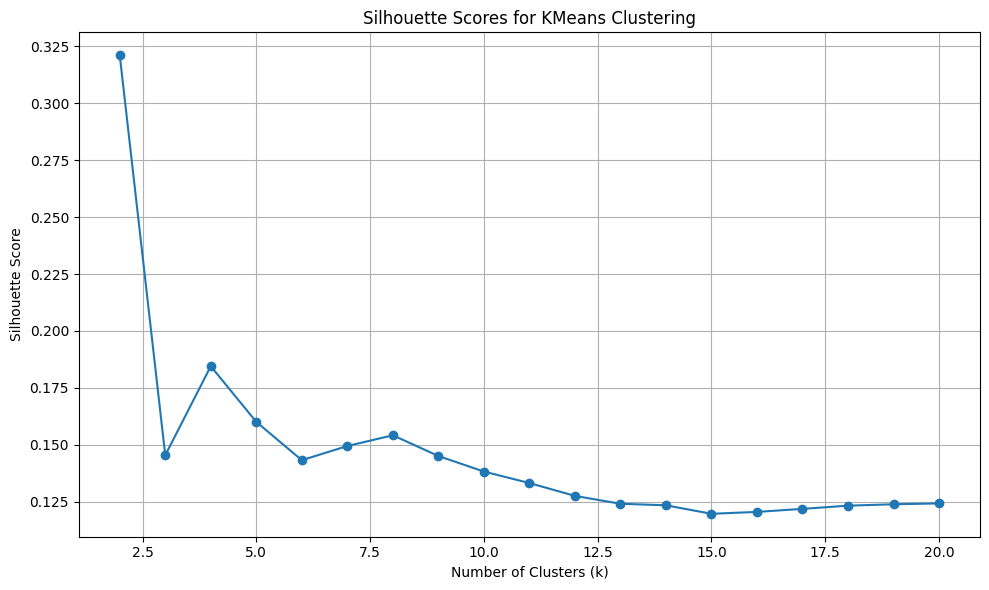

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []
K_range = range(2, 21)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=state)
    labels = kmeans.fit_predict(X_train_pca)
    score = silhouette_score(X_train_pca, labels)
    silhouette_scores.append(score)
    print(f"k={k}, silhouette score = {score:.4f}")


plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, marker='o')
plt.title("Silhouette Scores for KMeans Clustering")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.tight_layout()
plt.show()

Here I visualize the genres in 2D using the first two PCs. Clearly, we need at least a third dimension to have more interpretable visual separation as we can see how the genres are overlaid on each other in this 2D space.

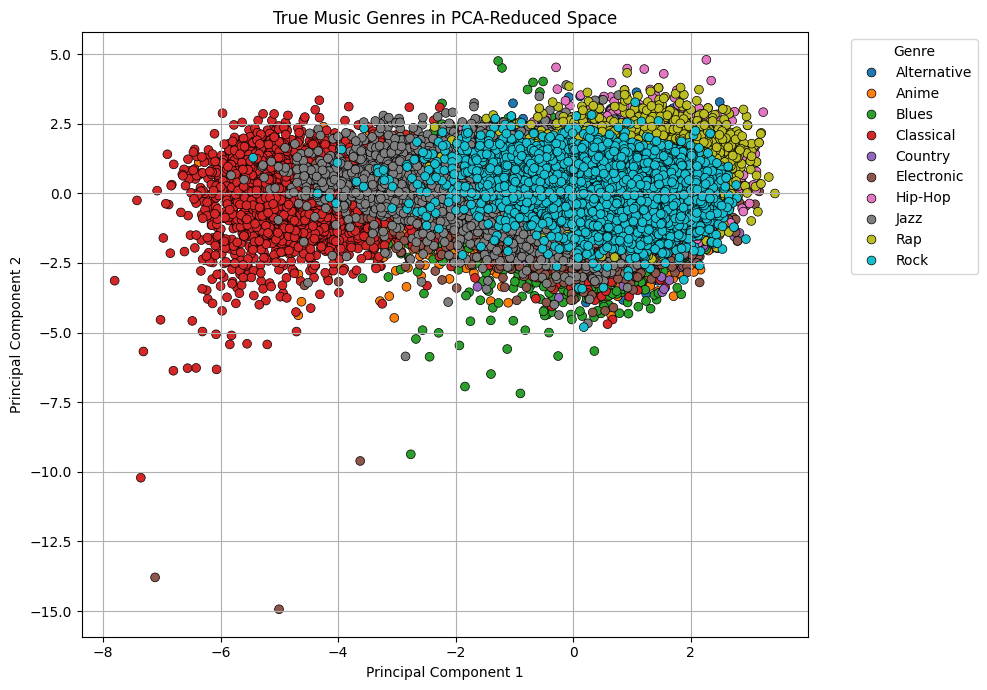

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_train_pca[:, 0], y=X_train_pca[:, 1],
    hue=y_train,
    palette='tab10',
    s=40, edgecolor='k'
)

plt.title("True Music Genres in PCA-Reduced Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Genre", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

And as suspected earlier, the KMeans clustering is not picking up on meanginful structures in the data to cluster the genres in this 2D space as we compare the real clusters above with what KMeans finds and see that it has identified nothing meaningful. KMeans clustering with PCA in 2D is not useful.

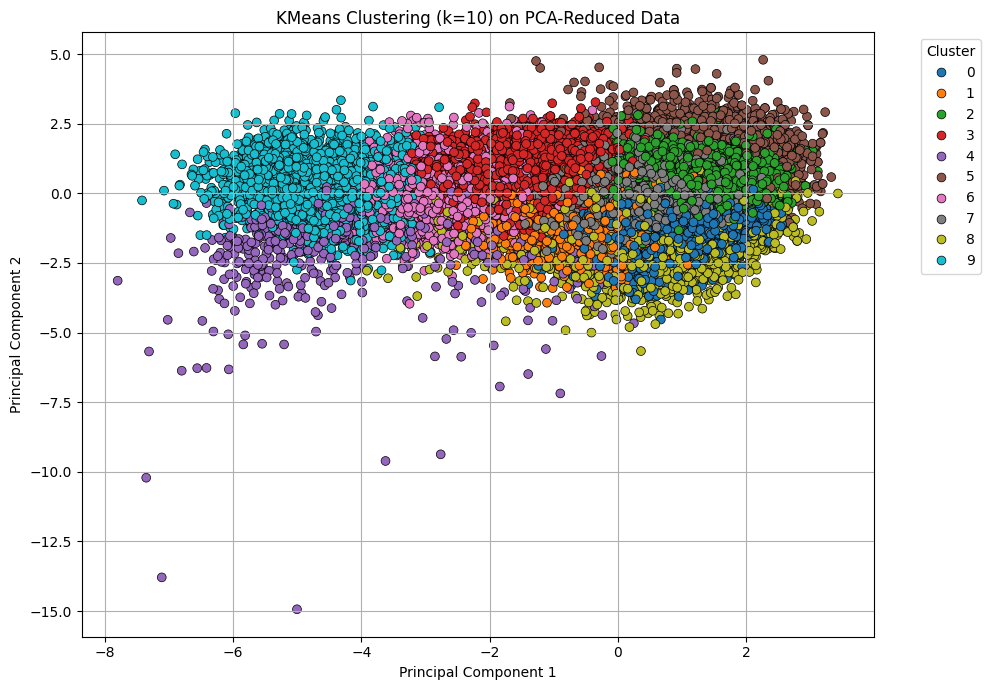

In [ ]:
kmeans = KMeans(n_clusters=10, random_state=42, n_init='auto')
train_clusters_10 = kmeans.fit_predict(X_train_scaled)
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_train_pca[:, 0],
    y=X_train_pca[:, 1],
    hue=train_clusters_10,
    palette='tab10',
    s=40,
    edgecolor='k'
)

plt.title("KMeans Clustering (k=10) on PCA-Reduced Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

Now I run some logistic regression with a couple different regularization values and on the raw unscaled data, raw scaled data, and PCA data to see which performs best. This serves as the baseline to compare our tree-based models too since Logistic Regression is pretty simplistic in its linear assumptions.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
import pandas as pd

y_train_bin = label_binarize(y_train_enc, classes=range(len(le.classes_)))
y_test_bin = label_binarize(y_test_enc, classes=range(len(le.classes_)))

logreg_results = {}

In [ ]:
lr_raw = LogisticRegression(solver='liblinear', max_iter=5000)
params = {'C': [0.01, 0.1, 1, 10]}

grid_raw = GridSearchCV(lr_raw, params, scoring='accuracy', cv=3)
grid_raw.fit(X_train, y_train_enc)

probs_raw = grid_raw.predict_proba(X_test)
auc_raw = roc_auc_score(y_test_bin, probs_raw, multi_class='ovr', average='macro')

logreg_results['Raw (Unscaled)'] = {
    'AUROC': auc_raw,
    'Best C': grid_raw.best_params_['C']
}

In [ ]:
lr_scaled = LogisticRegression(solver='liblinear', max_iter=5000)
grid_scaled = GridSearchCV(lr_scaled, params, scoring='accuracy', cv=3)
grid_scaled.fit(X_train_scaled, y_train_enc)

probs_scaled = grid_scaled.predict_proba(X_test_scaled)
auc_scaled = roc_auc_score(y_test_bin, probs_scaled, multi_class='ovr', average='macro')
logreg_results['Raw (Scaled)'] = {
    'AUROC': auc_scaled,
    'Best C': grid_scaled.best_params_['C']
}

In [ ]:
lr_pca = LogisticRegression(solver='liblinear', max_iter=5000)
grid_pca = GridSearchCV(lr_pca, params, scoring='accuracy', cv=3)
grid_pca.fit(X_train_pca, y_train_enc)

probs_pca = grid_pca.predict_proba(X_test_pca)
auc_pca = roc_auc_score(y_test_bin, probs_pca, multi_class='ovr', average='macro')
logreg_results['PCA-Reduced'] = {
    'AUROC': auc_pca,
    'Best C': grid_pca.best_params_['C']
}

We find that scaling and dimensionality reduction significantly improve performance for logistic regression, which makes sense since it's sensitive to scale and doesn't work well with nonlinear relationships. Scaling also smooths the optimization landscape and makes it so the LR can't handle as much regularization which is why there's so little regularization in scaled and PCA than unscaled (10 vs. 0.01). AUC of 0.8837 is also quite strong! So it indicates we are on the right track with all of our preprocessing.

In [ ]:
for name, result in logreg_results.items():
    print(f"{name} → AUROC: {result['AUROC']:.4f}, Best C: {result['Best C']}")

Raw (Unscaled) → AUROC: 0.7755, Best C: 0.01
Raw (Scaled) → AUROC: 0.8872, Best C: 10
PCA-Reduced → AUROC: 0.8837, Best C: 10


Next we try a default random forest classifier and already find AUC improve to 0.917. For the grid search I picked hypeparameters that aimed to balance model complexity, performance, and generalizability. I found the best performance came from n_estimators of 200, max_depth of 20, min_samples_split of 5, and max_features as 'sqrt'. This yielded an AUC of 0.9238.

This makes sense since 200 trees would give the model enough diversity to reduce variance without becoming too slow or redundant, capping depth at 20 helps avoid overfitting but you can still capture meaningful structure int he data, needing 5 samples to split regularizes the model a bit by preventing it from relying on noise or overly specific patterns, and 'sqrt' is the standard method of classification that probably helped here as it introduced variation between trees, boosting ensemble strength.

I also attempted to fit this same tree on the raw scaled data and the PCA-reduced data and found slightly lower performance at AUCs of 0.9237 and 0.9091 respectively. Well, scaled and unscaled essentially had indentical performance but with PCA-reduced it was considerably lower.

I suspect this is because Random Forests don’t benefit much from PCA since they already handle high-dimensional, non-linear data quite well without needing orthogonal transformations. PCA reduces dimensionality by combining features based on variance, but that can actually remove useful signals for tree-based models. RFs are also are scale-invariant, which we confirm here.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=state, n_jobs=-1)
rf.fit(X_train,y_train)
probs_rf = rf.predict_proba(X_test)
auc = roc_auc_score(y_test_bin, probs_rf, multi_class='ovr', average='macro')

In [ ]:
auc

np.float64(0.9170893333333334)

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20, 30],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=state, n_jobs=-1)
grid_rf = GridSearchCV(rf, param_grid, scoring='accuracy', cv=3, verbose=1)
grid_rf.fit(X_train, y_train)

probs_rf = grid_rf.predict_proba(X_test)
auc_rf = roc_auc_score(y_test_bin, probs_rf, multi_class='ovr', average='macro')

rf_results = {
    'AUROC': auc_rf,
    'Best Params': grid_rf.best_params_
}


print(f"Random Forest AUROC: {auc_rf:.4f}")
print("Best Parameters:", grid_rf.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Random Forest AUROC: 0.9238
Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}


In [ ]:
rf_best = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    max_features='sqrt',
    min_samples_split=5,
    random_state=state,
    n_jobs=-1
)

rf_best.fit(X_train_scaled, y_train_enc)
probs_scaled = rf_best.predict_proba(X_test_scaled)
auc_scaled = roc_auc_score(y_test_bin, probs_scaled, average='macro', multi_class='ovr')

rf_best.fit(X_train_pca, y_train_enc)
probs_pca = rf_best.predict_proba(X_test_pca)
auc_pca = roc_auc_score(y_test_bin, probs_pca, average='macro', multi_class='ovr')

print(f"RF AUROC (Scaled): {auc_scaled:.4f}")
print(f"RF AUROC (PCA-Reduced): {auc_pca:.4f}")

RF AUROC (Scaled): 0.9237
RF AUROC (PCA-Reduced): 0.9091


Next I tried GBDT, in this case HistGradientBoostingClassifier which I learned is a faster version since it bins continuous features into discrete histograms, reducing the number of candidate splits it has to evaluate. So it pairs well with this structured classification problem.

To this extent I tried fitting a default HistGBDT on raw unscaled data and got an AUC of 0.9318. This is higher than our best RF!

Afterwards I also defined a hyperparemter space to search that again aimed to find a model that would balance model complexity, performance, and generalizability. The best combination I found was learning_rate 0.05, max_iter 100, max_depth None and l2_regularization of 1.0.

These were likely the best performers because 0.05 learning rate lets the model learn gradually, preventing overfitting while still capturing meaningfull patterns and also smooths out the influence of individual trees. max_iter of 100 lets the model have enough boosting roudns to converge without overfitting too much, while max_depth of None lets each tree fit complex interactions if it so desires. This is good since we have a lot of features with different types of relationships (linear or non-linear). The l2_regularization of 1.0 gives some constraint on the leafs so we don't get predictions that are too sharp so this also helps with generalization (keeps us from relying too much on noise).

However, what's really interesting is that despite all the values in this grid search being present for it to recreate the default tree with 0.9318 AUC, it ended up choosing a combination with an extremely minisculely lower AUC of 0.9315. I think this difference is due to the introduction of 3-fold CV when doing the grid search so there is some stochasticity which lead to this. Basically, I think it is safe to say both have essentially the same, strong performance.

An AUC of 0.93 indicates that the model is able to predict genre really well based on the raw, unscaled features. With scaling it's 0.9311 (essentially identical), which makes sense as HistGBDT is mostly scale-invariant. The PCA-reduced had a lower AUC of 0.9137 for the same reason RF has lower performance with PCA-reduced. Essentially, dimensionality reduction is not helpful with tree based ensemble methods for this use case.


In [24]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb = HistGradientBoostingClassifier(random_state=state)
gb.fit(X_train, y_train_enc)
probs_gb = gb.predict_proba(X_test)
auc_gb = roc_auc_score(y_test_bin, probs_gb, average='macro', multi_class='ovr')

auc_gb

np.float64(0.9318227111111111)

In [ ]:
gb_model = HistGradientBoostingClassifier(random_state=state)

param_grid = {
    'learning_rate': [0.05, 0.1],
    'max_iter': [100, 200],
    'max_depth': [None, 10],
    'l2_regularization': [0.0, 1.0],
}

grid_gb = GridSearchCV(
    gb_model,
    param_grid,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1
)
grid_gb.fit(X_train_scaled, y_train_enc)

probs = grid_gb.predict_proba(X_test_scaled)
auc = roc_auc_score(y_test_bin, probs, average='macro', multi_class='ovr')

print(f"Best AUROC: {auc:.4f}")
print("Best Params:", grid_gb.best_params_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best AUROC: 0.9315
Best Params: {'l2_regularization': 1.0, 'learning_rate': 0.05, 'max_depth': None, 'max_iter': 100}


In [ ]:
gb_best = HistGradientBoostingClassifier(
  learning_rate = 0.05,
  l2_regularization = 1.0,
  max_depth = None,
  max_iter = 100
)

gb_best.fit(X_train_scaled, y_train_enc)
probs_scaled = gb_best.predict_proba(X_test_scaled)
auc_scaled = roc_auc_score(y_test_bin, probs_scaled, average='macro', multi_class='ovr')

gb_best.fit(X_train_pca, y_train_enc)
probs_pca = gb_best.predict_proba(X_test_pca)
auc_pca = roc_auc_score(y_test_bin, probs_pca, average='macro', multi_class='ovr')

print(f"GB AUROC (Scaled): {auc_scaled:.4f}")
print(f"GB AUROC (PCA-Reduced): {auc_pca:.4f}")

GB AUROC (Scaled): 0.9311
GB AUROC (PCA-Reduced): 0.9137


RF is a bagging method where many trees are trained independently on random subsets of the data before averaging there outputs. HistGBDT is a boosting method where trees are built sequentially and each new tree is learning and correcting the errors of its predecessor. In this case I think HistGBDT did better because likely this data has subtle patterns and some genres are definitely harder to classify that others.

There's surely quite a bit of variation, we saw in the earlier PCA some genres such as classical are very spread across these features. Boosting is better at capturing these types of things and the binning probably helped to smooth out noisy features too (we see early many non-normal and skewed distributions with relatively weak feature correlations). So I think it was able to find a slightly better point in the bias vs. variance tradeoff than RF. That being said, let's look below at how each performed on different genres!

In [28]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    max_features='sqrt',
    random_state=state
)
rf.fit(X_train, y_train_enc)
rf_probs = rf.predict_proba(X_test)

gbdt = HistGradientBoostingClassifier(
    l2_regularization=1.0,
    learning_rate=0.05,
    max_iter=100,
    max_depth=None,
    random_state=state
)
gbdt.fit(X_train, y_train_enc)
gbdt_probs = gbdt.predict_proba(X_test)

print("AUROC by genre:")
for i, genre in enumerate(le.classes_):
    rf_auc = roc_auc_score(y_test_bin[:, i], rf_probs[:, i])
    gbdt_auc = roc_auc_score(y_test_bin[:, i], gbdt_probs[:, i])
    print(f"{genre:12s} | RF AUC: {rf_auc:.4f} | GBDT AUC: {gbdt_auc:.4f}")

AUROC by genre:
Alternative  | RF AUC: 0.8549 | GBDT AUC: 0.8732
Anime        | RF AUC: 0.9673 | GBDT AUC: 0.9712
Blues        | RF AUC: 0.9053 | GBDT AUC: 0.9124
Classical    | RF AUC: 0.9766 | GBDT AUC: 0.9798
Country      | RF AUC: 0.9295 | GBDT AUC: 0.9337
Electronic   | RF AUC: 0.9274 | GBDT AUC: 0.9282
Hip-Hop      | RF AUC: 0.9092 | GBDT AUC: 0.9277
Jazz         | RF AUC: 0.9205 | GBDT AUC: 0.9254
Rap          | RF AUC: 0.9011 | GBDT AUC: 0.9211
Rock         | RF AUC: 0.9365 | GBDT AUC: 0.9467


HistGBDT has higher performance across the board than RF! Also the genres with the worst performance are alternative and blues. Alternative definitely makes since that's a very varied genre, and Anime and Classical being the easiest to classify also makes sense since they have very distinct styles.

So far, so good. It's just come to me as I type this that ChatGPT types like this when its prompted for help (which I know since I was trying to do my deceptive AI assignment thing), and I want to clarify that I really am doing these writeups myself, and I truly just sound and write like this. I just feel like it's nice to have my notebook playout like a conversation with someone, for the most part. Makes it easier to follow, maybe? It definitely makes it much, much easier for me to write since it's very stream of consciousness which keeps me from getting stuck. I'm very sorry for how long this notebook is and how long the report is. I just feel like I always have a lot to say and truth be told, I didn't have the time to go back and consolidate this work, only enough to get it out. Rough week (month).

That being said, let's look at what types of misclassifications it's making!

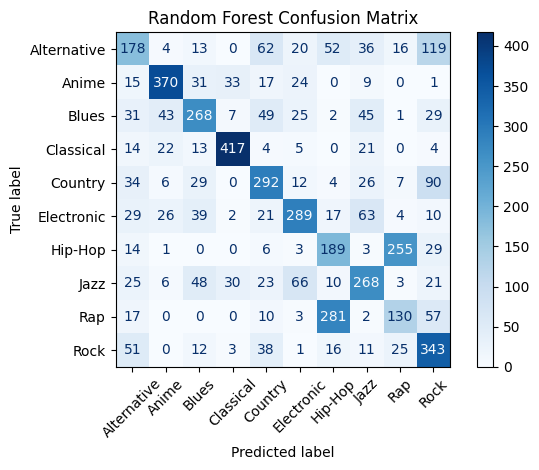

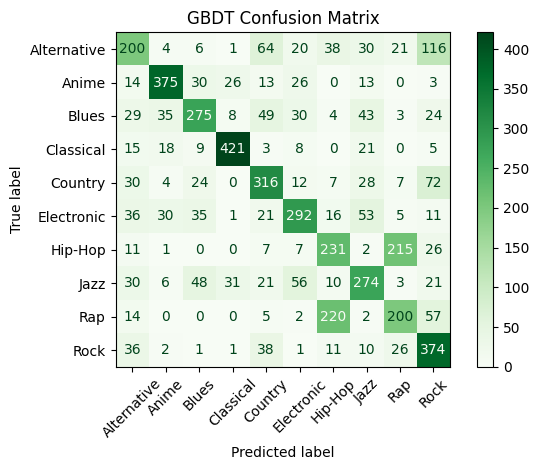

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

rf_preds = rf.predict(X_test)
gbdt_preds = gbdt.predict(X_test)

cm_rf = confusion_matrix(y_test_enc, rf_preds)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=le.classes_)
disp_rf.plot(xticks_rotation=45, cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

cm_gbdt = confusion_matrix(y_test_enc, gbdt_preds)
disp_gbdt = ConfusionMatrixDisplay(confusion_matrix=cm_gbdt, display_labels=le.classes_)
disp_gbdt.plot(xticks_rotation=45, cmap='Greens')
plt.title("GBDT Confusion Matrix")
plt.tight_layout()
plt.show()

We see rock and alternative get confused a lot, and so do hip-hop and rap, in both models. I think these are pretty reasonable errors. Genre classifications are blurry even to me. Sometimes it really is more of a spectrum. Concerning errors such as classical and hip-hop don't really exist, so that's a good sign. Just to make it simpler, there's another method of identifying these below.

In [30]:
genre_map = dict(zip(range(len(le.classes_)), le.classes_))

misclassified_rf = pd.DataFrame({
    'True': [genre_map[t] for t in y_test_enc],
    'Predicted_RF': [genre_map[p] for p in rf_preds]
})
misclassified_rf = misclassified_rf[misclassified_rf['True'] != misclassified_rf['Predicted_RF']]
print("Random Forest Misclassifications:")
print(misclassified_rf.value_counts().head(10))

misclassified_gbdt = pd.DataFrame({
    'True': [genre_map[t] for t in y_test_enc],
    'Predicted_GBDT': [genre_map[p] for p in gbdt_preds]
})
misclassified_gbdt = misclassified_gbdt[misclassified_gbdt['True'] != misclassified_gbdt['Predicted_GBDT']]
print("\nGBDT Misclassifications:")
print(misclassified_gbdt.value_counts().head(10))


Random Forest Misclassifications:
True         Predicted_RF
Rap          Hip-Hop         281
Hip-Hop      Rap             255
Alternative  Rock            119
Country      Rock             90
Jazz         Electronic       66
Electronic   Jazz             63
Alternative  Country          62
Rap          Rock             57
Alternative  Hip-Hop          52
Rock         Alternative      51
Name: count, dtype: int64

GBDT Misclassifications:
True         Predicted_GBDT
Rap          Hip-Hop           220
Hip-Hop      Rap               215
Alternative  Rock              116
Country      Rock               72
Alternative  Country            64
Rap          Rock               57
Jazz         Electronic         56
Electronic   Jazz               53
Blues        Country            49
Jazz         Blues              48
Name: count, dtype: int64
